In [1]:
from langchain.chat_models import init_chat_model
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class State(TypedDict):
    # Messages have type as annotated list
    # add_messages define how state key is updated
    # in this case it gets appended to the list, rather than overridding it
    messages : Annotated[list, add_messages]

In [3]:
@tool
def get_stock_price(symbol:str) -> float:
    '''Returns the current price of a stock given symbol
    :param symbol: stock symbol
    :return: current price of stock
    '''
    return{
        "MSFT":200.3,
        "IBM":300.7,
        "AAPL":100.4,
        "AMZN":150.1
    }.get(symbol, 0.0)

tools = [get_stock_price]


In [4]:
llm = init_chat_model(model="gpt-3.5-turbo")
llm_with_tools = llm.bind_tools(tools)

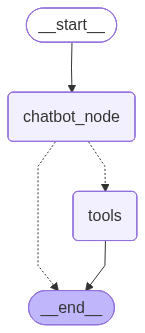

In [6]:
def chatbot(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
message = {"role":"user","content":"what is the prize of AMZN stocks?"}

response = graph.invoke({"messages":[message]})
print(response["messages"][-1].content)

150.1


In [12]:
message = {"role":"user","content":"what is the prize of IBM stocks?"}

response = graph.invoke({"messages":[message]})
print(response["messages"][-1].content)

300.7


In [ ]:
message = {"role":"user","content":"I want to buy 20 AMZN stocks. Then 10 IBM stocks. What will be total cost?"}

response = graph.invoke({"messages":[message]})
print(response["messages"][-1].content)

# Expected answer 20 x $150.10 + 10 x $300.70 = $6009

300.7


In [14]:
## Create an agent/ give reasoning capability to code

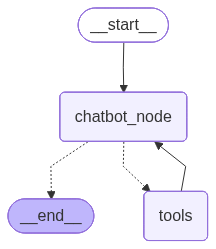

In [16]:
def chatbot(state: State) -> State:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
message = {"role":"user","content":"I want to buy 20 AMZN stocks. Then 10 IBM stocks. What will be total cost?"}

response = graph.invoke({"messages":[message]})
print(response["messages"][-1].content)

# Expected answer 20 x $150.10 + 10 x $300.70 = $6009

The current price of one AMZN stock is $150.10 and the current price of one IBM stock is $300.70. 

To calculate the total cost:
For 20 AMZN stocks = 20 * $150.10 = $3002
For 10 IBM stocks = 10 * $300.70 = $3007

Total cost = $3002 + $3007 = $6009
